# BLEU SCORE
The BLEU score is a metric used to measure how similar the model’s output is to a reference (human-written) text based on overlapping words.

Reference: https://aldosari.medium.com/evaluating-text-quality-with-bleu-score-in-python-using-nltk-f45f3b16c8e0


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.translate.bleu_score import sentence_bleu

df_results = pd.read_csv("results/output1.csv")

In [ ]:
# OUR REFERENCE TRANSLATIONS FOR BLEU
references = {
    1:  "dude I literally didn't understand anything in that lecture",
    2:  "I just don't get it man, this assignment makes absolutely no sense",
    3:  "it's really too much, I don't think we'll finish this on time",
    4:  "it was so cozy last night, we should definitely do this again sometime",
    5:  "I have no clue what we should eat, should we just order something",
    6:  "man the weather is so depressing, I don't want to go to the library",
    7:  "I'm so exhausted, I stayed up until like three o'clock last night",
    8:  "calm down man, you're making it way too complicated",
    9:  "I'm going to do groceries, what ingredients do you need for dinner?",
    10: "I'm really stressed for my exam, but I also need to get my driver's license",
    11: "I've applied for a lot of part-time jobs, but I keep not getting hired",
    12: "I find the grading of this assignment really unfair",
    13: "I always buy my birthday gifts at the bookstore",
    14: "during my internship I had a co-worker who talked way too much",
    15: "Bro I'm so stressed, I have so many deadlines this week",
    16: "They ghosted me, I can't believe it",
    17: "You just relax, it'll be fine",
    18: "He cancelled on me last minute, so rude",
    19: "Wow this outfit is so cute, where'd you get it",
    20: "That guy was so fake, I don't trust him at all",
    21: "Don't overthink so much, it'll all work out",
    22: "I ordered the groceries, they'll arrive in an hour",
    23: "I actually really like this show, it's so good",
    24: "I dont get why people always leave their dishes in the sink, is it really that difficult to clean?",
    25: "I went to the supermarket just to get milk and I ended up spending like 30 euros, it always goes like this",
    26: "I was supposed to go to the gym today but I kept snoozing my alarm, now I have been feeling guilty the whole day",
    27: "I am very tired, but I still have to finish my work tonight.",
    28: "Okay, let's order food, I'm not in the mood to cook.",
    29: "Why is this assignment so difficult, I don't understand it.",
    30: "I have so many deadlines this week, I am so stressed.",
    31: "I planned to watch a movie, but I don't think it's gonna happen this week.",
    32: "I am feeling sick, I think I caught a cold in Berlin.",
    33: "I went to Berlin for a holiday, but I didn't get to do anything fun there.",
    34: "I went to a King's Day party. It was so much fun, but I had to wake up early for work the next day.",
    35: "I just came back from my mom's place, I just had the best food ever, idiyappam and fish curry, such a good combination.",
    36: "I went to Saravana Bhavan to eat food, their vada idli set is pretty popular.",
    37: "I'm planning to go to India for the summer holidays, let's see if it's actually going to happen.",
    38: "I am watching a new series called 'Boyfriend on Demand'. I am totally addicted to it, what a story!",
    39: "I am desperately waiting to finish my studies. I hope soon.",
    40: "Can you help me writing this letter, I don't know how to start it?",
    41: "I am going to book an Uber, could you tell me where you are?",
    42: "I barely slept, I feel so sick.",
    43: "My WiFi isn't working, I can't do anything.",
    44: "I was at Patch Work today and wanted to buy a bicycle, but I didn't have enough money with me.",
    45: "I heard about the tulip season in the Netherlands, it must be such a nice view.",
    46: "My mom had to renew her passport, we had to go to the embassy together, it was such a hassle to get to Berlin.",
    47: "Are you sleeping, Are you sleeping, Brother John? Brother John? Morning bells are ringing, Morning bells are ringing, Ding, dong, ding.",
    48: "Twinkle twinkle little star, how I wonder what you are",
    49: "I have a meeting at 3 pm, can you tell me where the zoom link is?",
    50: "I am not hungry, I already ate",
    51: "I need to stop by the bank, could you tell me where the nearest one is?",
    52: "I have to go to the doctor, I am not feeling well",
 
}

bleu_scores = []
for idx, row in df_results.iterrows():
    reference = references[row["id"]].split()
    hypothesis = row["normalised"].split()
    score = sentence_bleu([reference], hypothesis)
    bleu_scores.append(score)

df_results["bleu_score"] = bleu_scores

pair_bleu = df_results.groupby("pair")["bleu"].mean()

print(pair_bleu)

pair
english-dutch     0.756096
english-german    0.694025
english-hindi     0.566035
english-tamil     0.745463
Name: bleu, dtype: float64


# Human Evaluation
Human evaluation reflects subjective judgments of translation quality, including accuracy, fluency, and tone preservation on a 1–10 scale. 


In [ ]:
# Create a rating excel sheet for us to fill in and rate all from 1-10
rating_template = df_results[["id", "pair", "languages_detected", "language_ratios", "prompt", "normalised", "lost_in_translation"]].copy()
# Does the normalised sentence preserve the original meaning
rating_template["accuracy_score"] = np.nan
# Does the output sound like natural English?
rating_template["fluency_score"] = np.nan
# Does the output preserve the tone?
rating_template["tone_score"] = np.nan
rating_template["overall_rating"] = np.nan

# The line below is commented to avoid overwriting the rating sheets with the scores that were filled in manually
# rating_template.to_csv("results/rating_sheet.csv", index=False)

# Each of us fills this in for their language pair

In [ ]:
df = pd.read_csv("results/rating_sheet.csv")

# ensure numeric
df["accuracy_score"] = pd.to_numeric(df["accuracy_score"], errors="coerce")
df["fluency_score"] = pd.to_numeric(df["fluency_score"], errors="coerce")
df["tone_score"] = pd.to_numeric(df["tone_score"], errors="coerce")

# compute overall rating
df["overall_rating"] = df[["accuracy_score", "fluency_score", "tone_score"]].mean(axis=1)

# save updated file WITH the new column
df.to_csv("results/rating_sheet.csv", index=False)

# BERTScore
The BERTScore measures semantic similarity between the generated and reference text using contextual embeddings, capturing meaning beyond exact word overlap.

In [8]:
predictions = []
refs = []

for idx, row in df_results[df_results["id"] <= 53].iterrows():
    predictions.append(row["normalised"])     
    refs.append(references[row["id"]])         

In [13]:
from bert_score import score

P, R, F1 = score(
    predictions,
    refs,
    model_type="distilbert-base-uncased",
    device="cpu",
    batch_size=2
)

print("BERTScore:", F1.mean().item())

C:\Users\amina\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\amina\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\amina\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingfa

BERTScore: 0.9661325216293335


# Visualisation

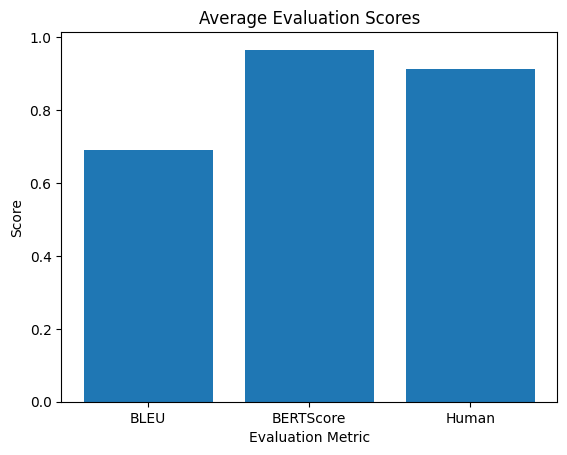

In [36]:
import matplotlib.pyplot as plt

bleu_avg = sum(bleu_scores) / len(bleu_scores)
bert_avg = F1.mean().item()
human_avg = df["overall_rating"].mean() / 10

plt.bar(["BLEU", "BERTScore", "Human"], [bleu_avg, bert_avg, human_avg])
plt.ylabel("Score")
plt.xlabel("Evaluation Metric")
plt.title("Average Evaluation Scores")
plt.show()

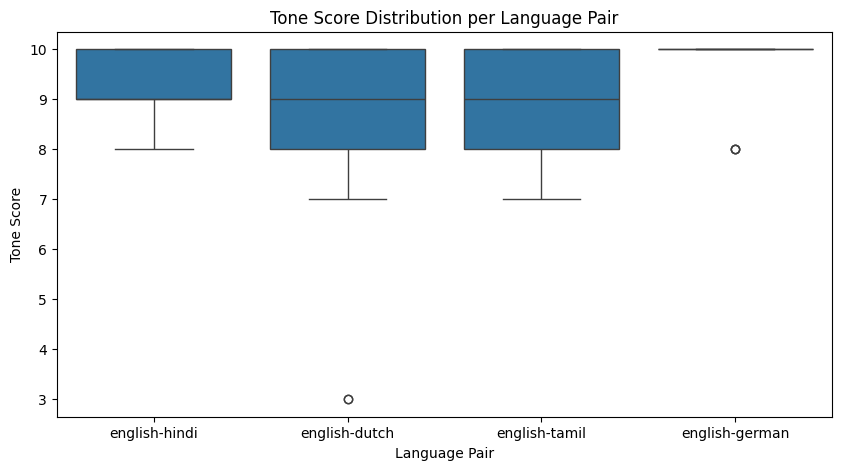

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

sns.boxplot(data=df, x="pair", y="tone_score")

plt.title("Tone Score Distribution per Language Pair")
plt.ylabel("Tone Score")
plt.xlabel("Language Pair")

plt.show()

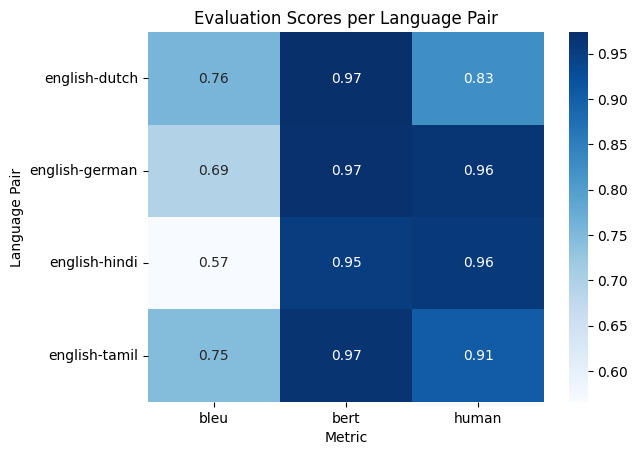

In [29]:
df_results["bleu"] = bleu_scores
df_results["bert"] = bert_scores
df_results["human"] = df["overall_rating"]/10

df_plot = df_results.groupby("pair")[["bleu", "bert", "human"]].mean()

sns.heatmap(df_plot, annot=True, cmap="Blues", fmt=".2f")

plt.title("Evaluation Scores per Language Pair")
plt.xlabel("Metric")
plt.ylabel("Language Pair")
plt.show()

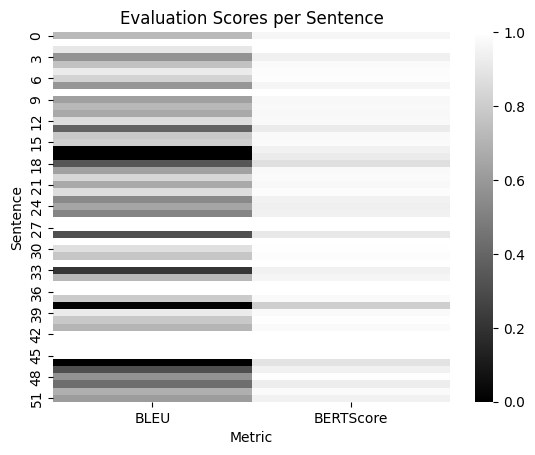

In [47]:
df_plot = pd.DataFrame({
    "BLEU": bleu_scores,
    "BERTScore": bert_scores
})

sns.heatmap(df_plot, cmap="gray")

plt.title("Evaluation Scores per Sentence")
plt.xlabel("Metric")
plt.ylabel("Sentence")

plt.show()